# Pima-Indians-Diabetes Model Tuning and validation.
### Analystlab Africa Machine learning internship 
This notebook is for the week 6 of the analystlab africa machine learning internship.
in this notebook i will be mostly performing model tuning and validation so i will do a basic cleaning and then proceed to the tuning.

question: why not clean and feature engineer well ?

answer: to show the power of model tuning and validation and also becaause i am out of time.

### **About the Pima-Indians-Diabetes dataset**
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

`The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.`

### Goal
To optimize and validate a Machine Learning model using hyperparameter tuning and validation techniques to improve predictive performance and reliability.

### Task Breakdown

1. Hyperparameter Tuning

Study and apply the following techniques:

- Grid Search
- Random Search
- Parameter selection and optimization
- Model performance comparison

2. Cross-Validation

Learn how to evaluate model performance using:

- K-Fold Cross-Validation
- Train/Test Split Validation
- Cross-validation scoring

3. Bias-Variance Tradeoff

Understand and explain:

- Overfitting
- Underfitting
- Model generalization
- Strategies for balancing bias and variance

## Step 1: Importing Libraries and Dataset 

In [75]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score,f1_score
from sklearn.metrics import roc_curve

from sklearn.tree import DecisionTreeClassifier

In [2]:
# importing the dataset here 
data_path = "/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv"
pima_df = pd.read_csv(data_path)


In [3]:
pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Sub-Phase 1.1: what do the columns in the data mean 

 |Columns|Description|
 |-------|-----------|
 |Pregnancies|Number of times pregnant|
 |Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
 |BloodPressure|Diastolic blood pressure (mm Hg)|
 |SkinThickness|Triceps skin fold thickness (mm)|
 |Insulin|2-Hour serum insulin (mu U/ml)|
 |BMI|Body mass index (weight in kg/(height in m)^2)|
 |DiabetesPedigreeFunction|Diabetes pedigree function|
 |Age|Age (years)|
 |Outcome|Class variable (0 or 1) 268 of 768 are 1, the others are 0|

## Step 2: Exploratory Data Analysis (EDA)

In [4]:
# lets check the shape of the data 
pima_shape = pima_df.shape

print(f"Rows: {pima_shape[0]} with Columns: {pima_shape[1]}")

Rows: 768 with Columns: 9


In [5]:
# lets check the statistics 
pima_df.describe()
print("someone has a blood pressure of 122 thats too high !!!")

someone has a blood pressure of 122 thats too high !!!


In [6]:
#checking for duplicate column 
print(f" The duplicated rows are: {pima_df.duplicated().sum()}")

 The duplicated rows are: 0


In [7]:
# checking out the missing data in the dataset 
is_null_here = pima_df.isna().sum() / len(pima_df) * 100
is_nulldf = pd.DataFrame({"column": is_null_here.index, "Percent_missing":is_null_here.values})

display(is_nulldf)
print("clean dataset cool")

,column,Percent_missing
0,Pregnancies,0.0
1,Glucose,0.0
2,BloodPressure,0.0
3,SkinThickness,0.0
4,Insulin,0.0
5,BMI,0.0
6,DiabetesPedigreeFunction,0.0
7,Age,0.0
8,Outcome,0.0


clean dataset cool


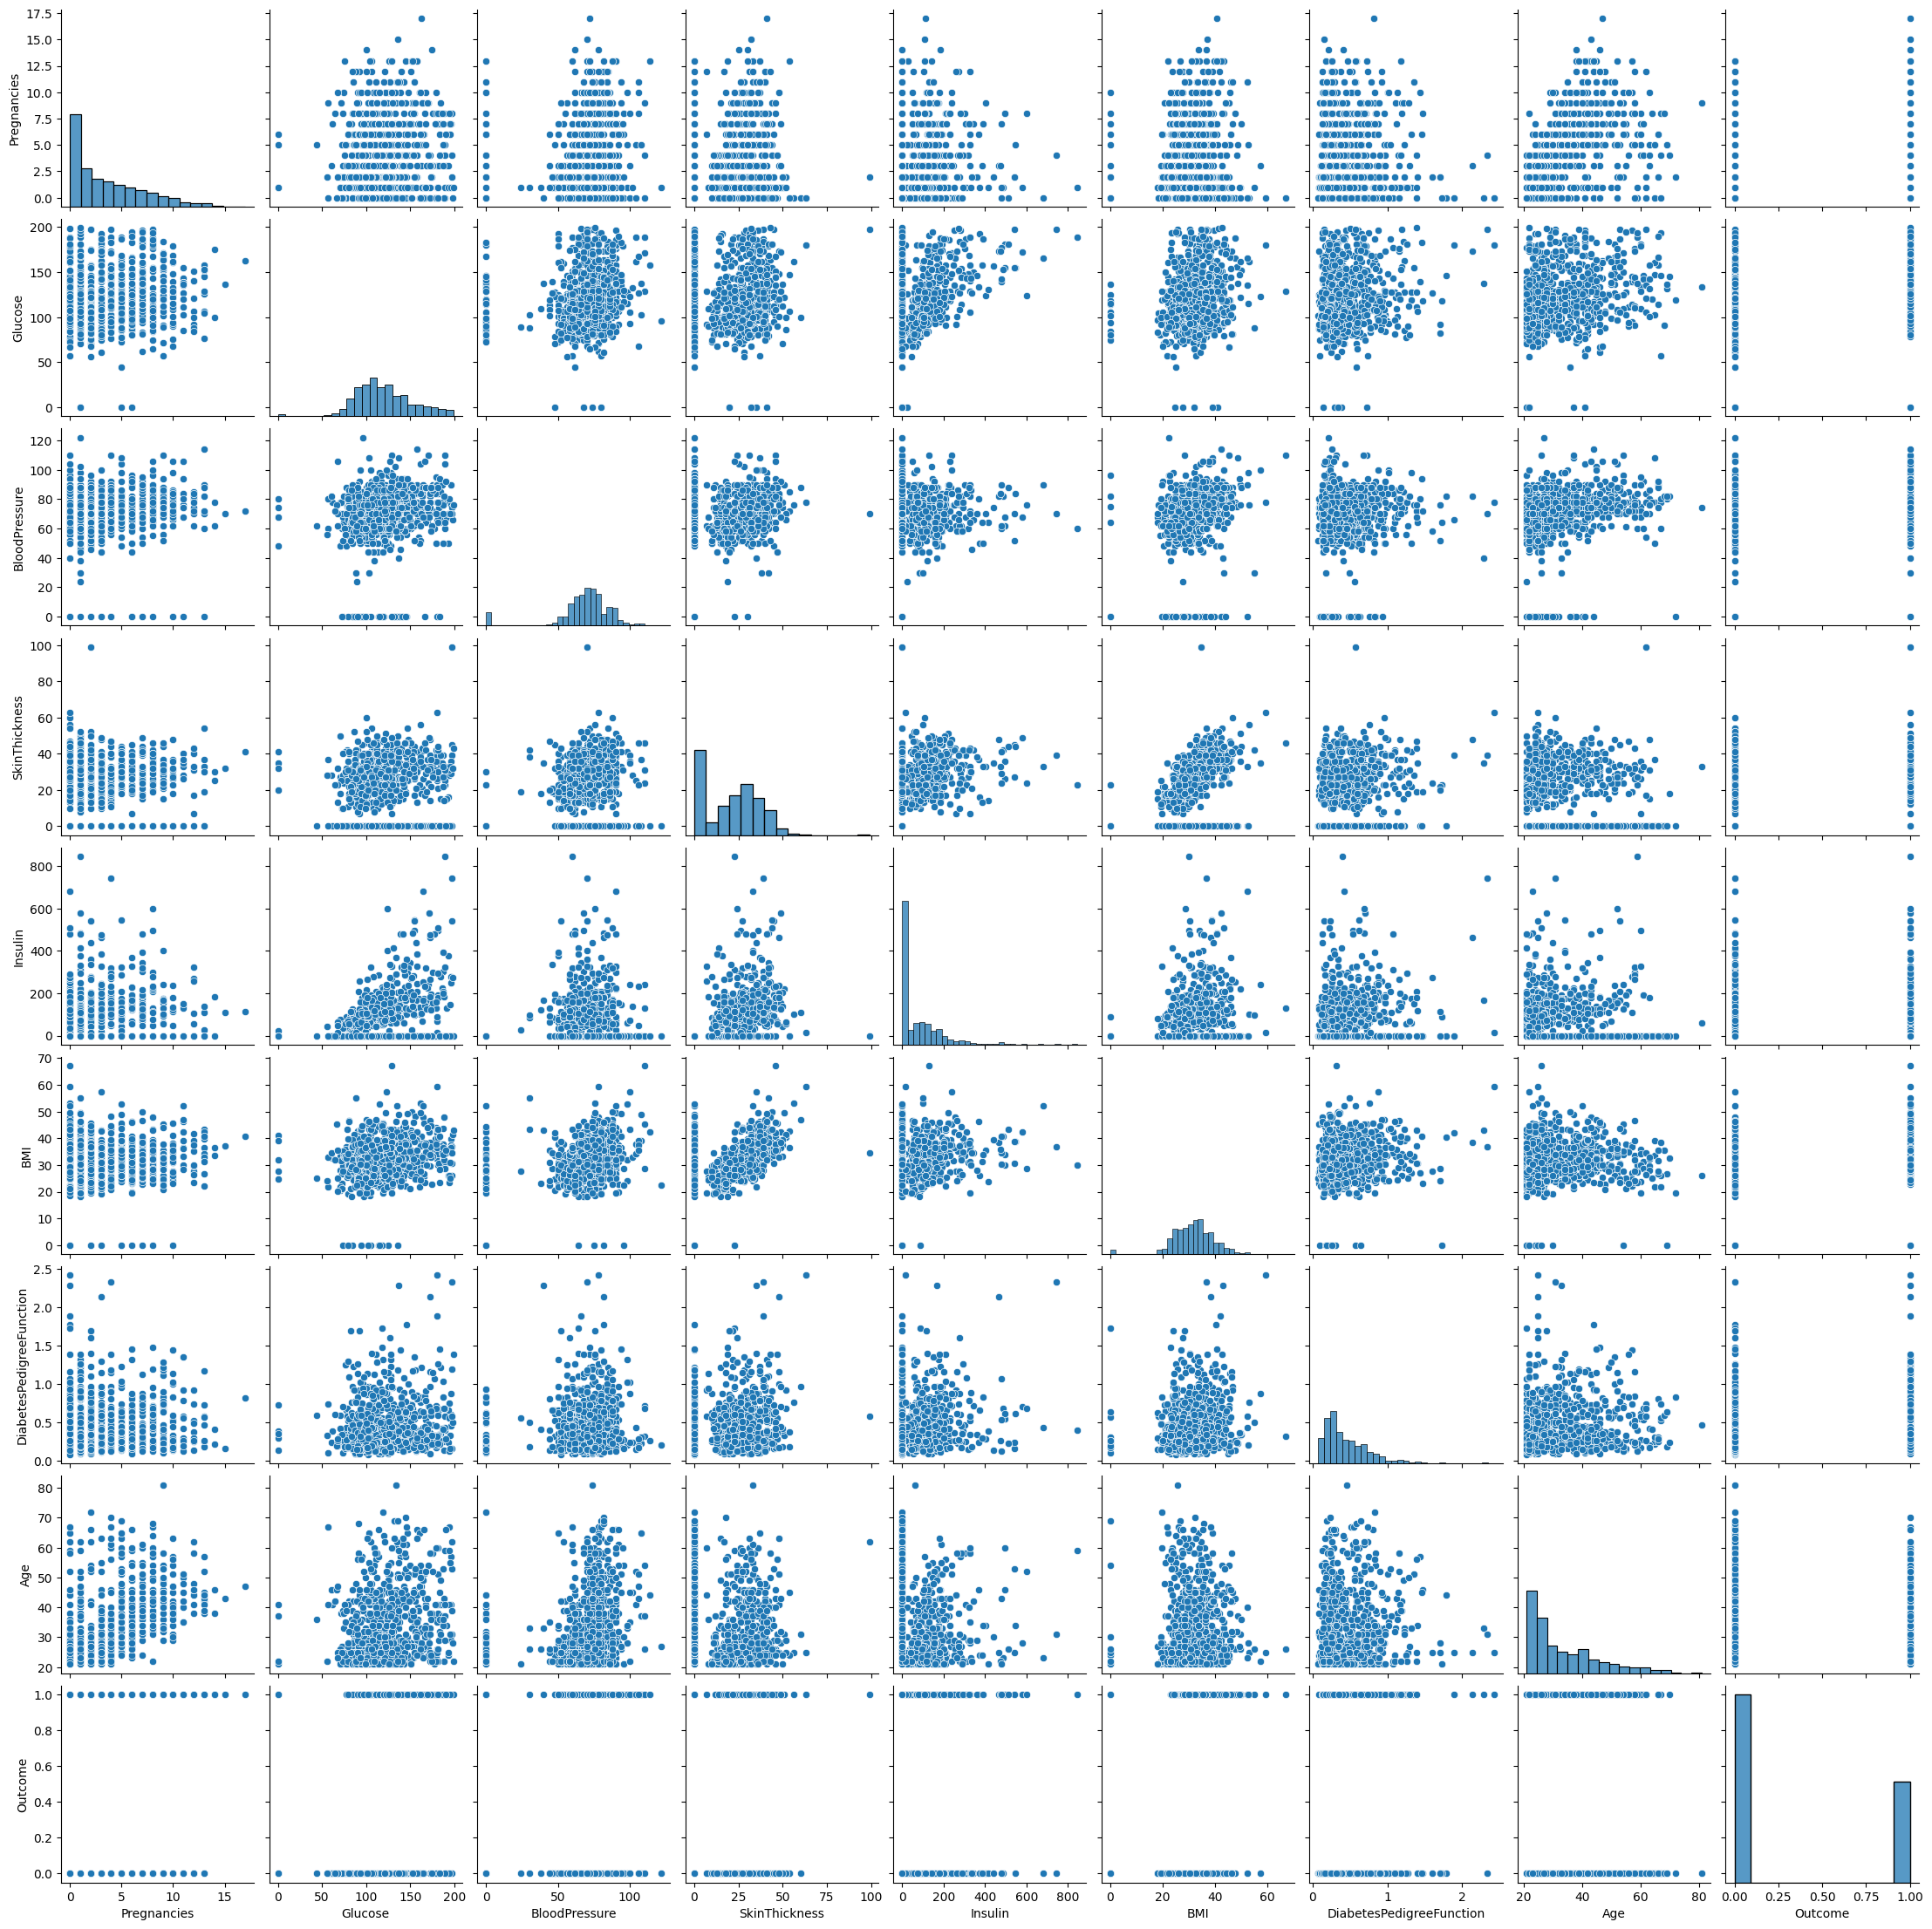

In [8]:
sns.pairplot(pima_df)

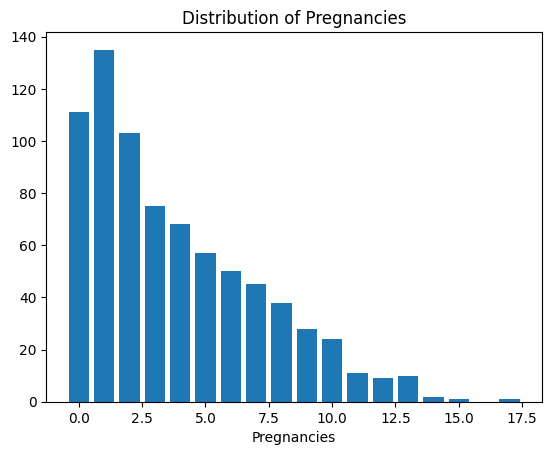

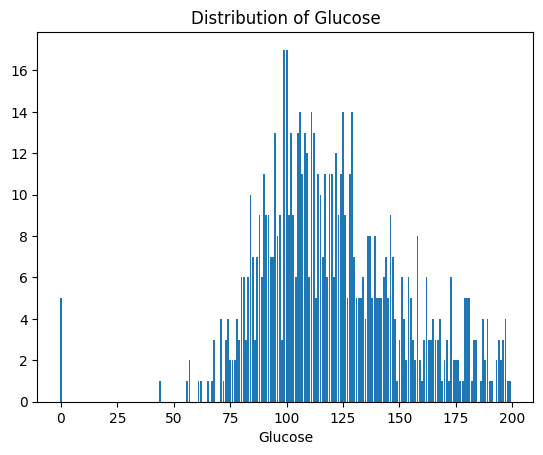

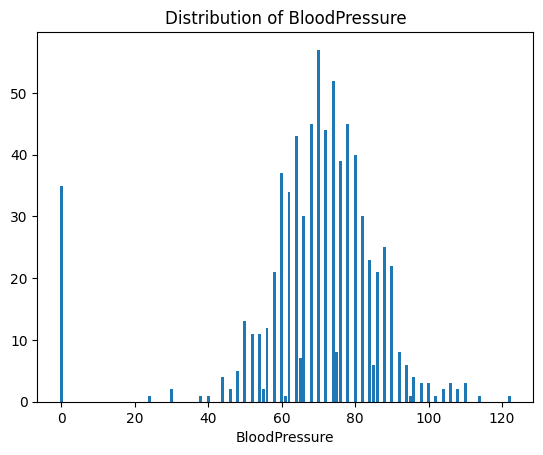

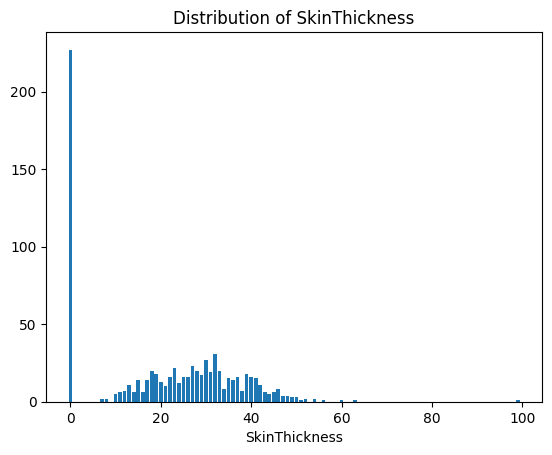

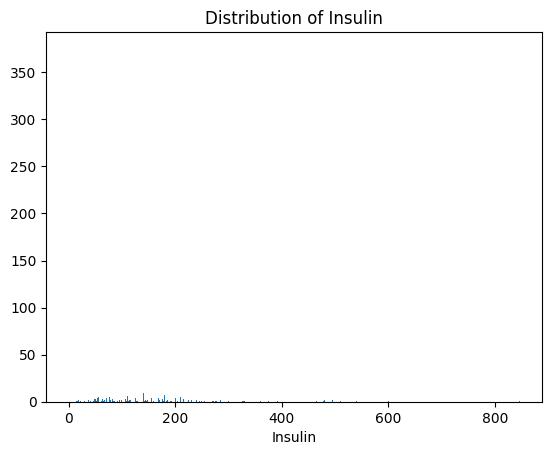

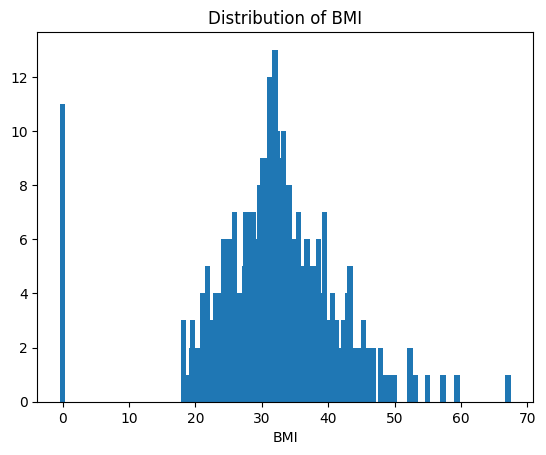

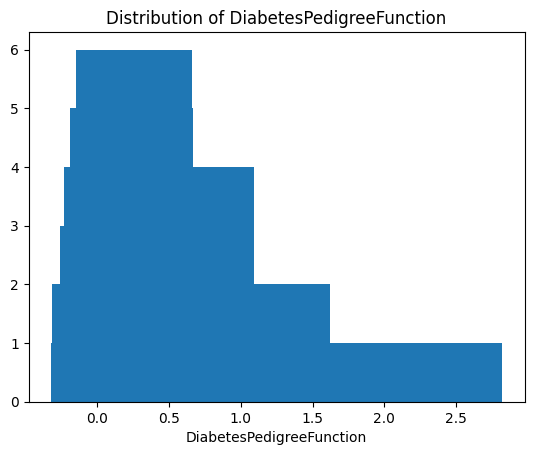

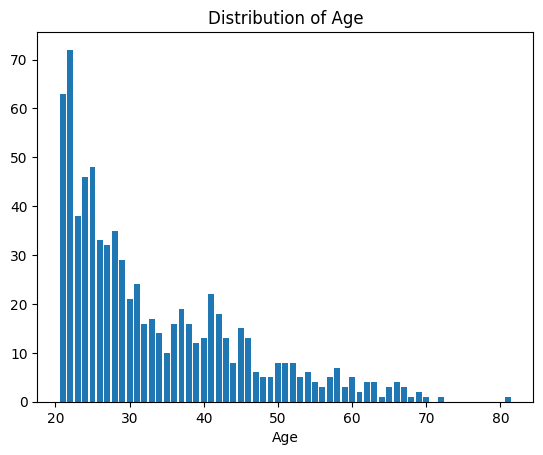

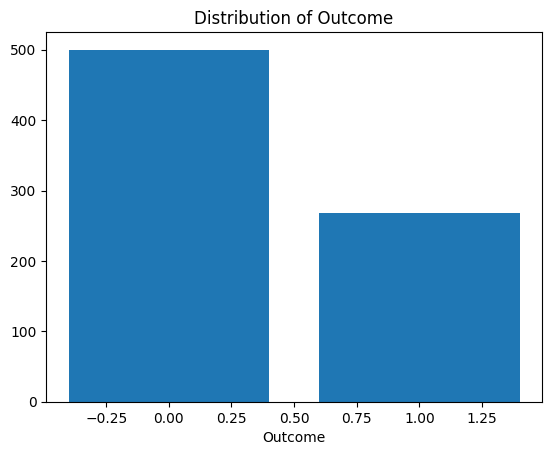

In [9]:
# checking out the distribution of the data 
def plot_distribution(df):
    """
    plots a histogram of the column situation 
    """
    for column in df.columns:
        df_val_counts = df[column].value_counts()
        plt.bar(df_val_counts.index, df_val_counts.values,align='center')
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.show()

plot_distribution(pima_df)

In [10]:
def plot_relationship(df,column_1, column_2):
    """
    This function plots a scatter plot of two columns with relationship
    with the target column
    """
    
    fig, ax = plt.subplots(figsize = (7,5))
    ax.scatter(pima_df[column_1], pima_df[column_2], c = pima_df["Outcome"])
    ax.set_title(f" Relationship between {column_1} and {column_2}")
    ax.set_xlabel(column_1)
    ax.set_ylabel(column_2)
    ax.legend(pima_df["Outcome"])
    plt.show()

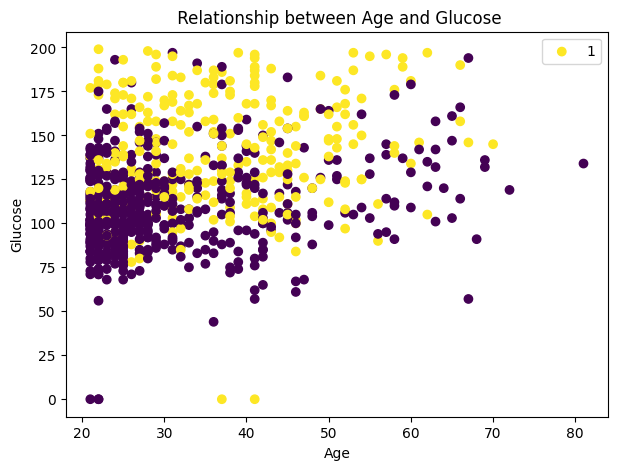

In [11]:
# lets plot the relationship between age and glucose with respect to Outcome
plot_relationship(pima_df,"Age", "Glucose")

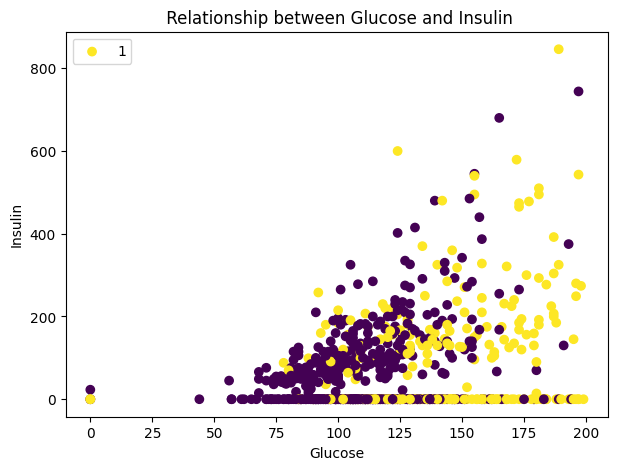

In [12]:
# lets plot the relationship between age and glucose with respect to Outcome
plot_relationship(pima_df, "Glucose", "Insulin")

In [13]:
def plot_box(df):
    for column in df.columns:
        plt.boxplot(df[column])
        plt.title(f"Box plot of {column} column")
        plt.xlabel(column)
        plt.show()

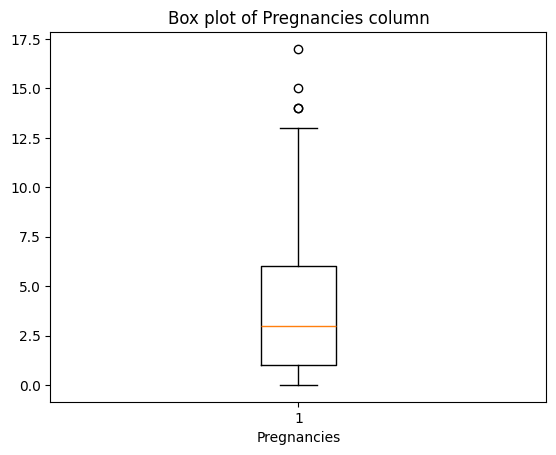

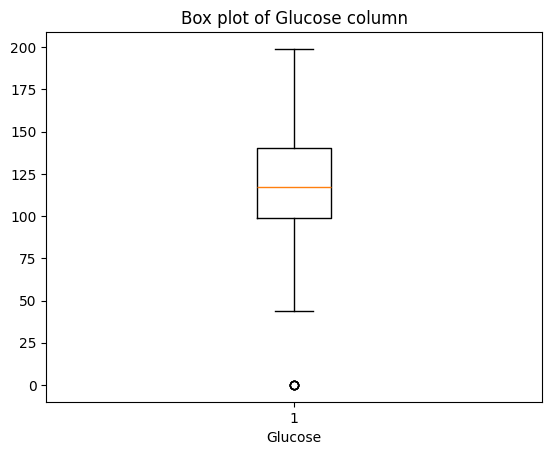

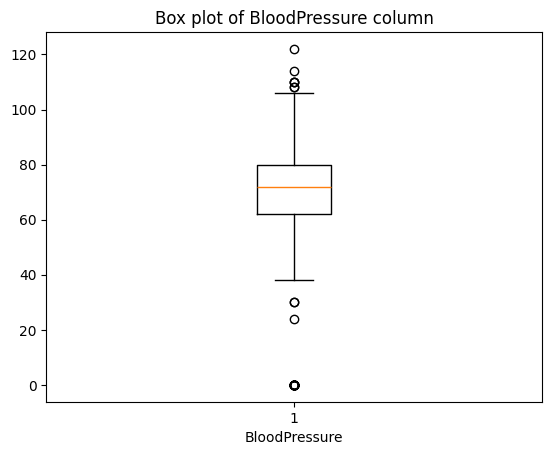

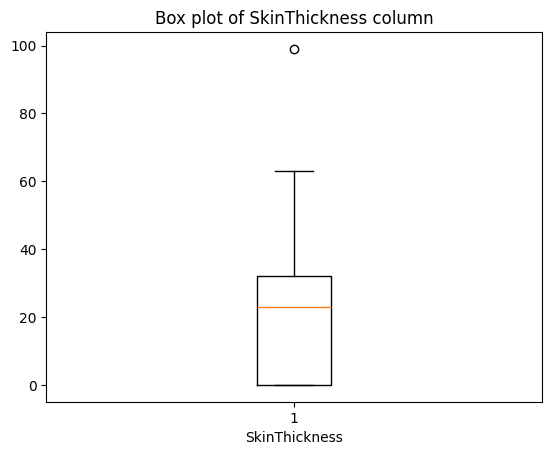

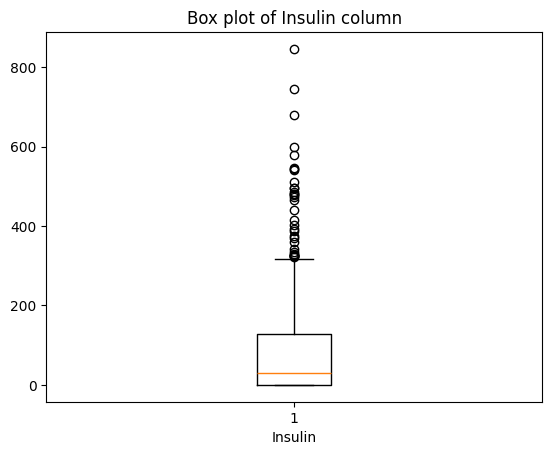

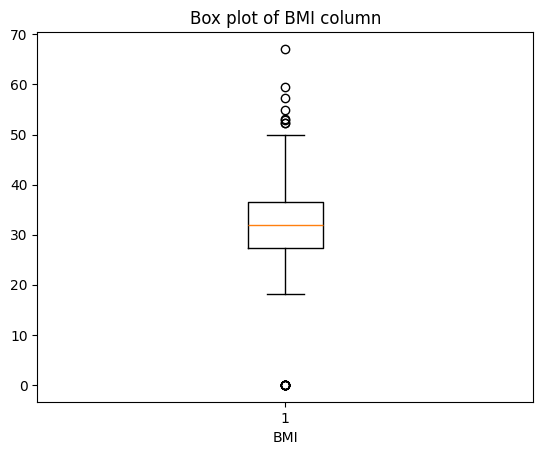

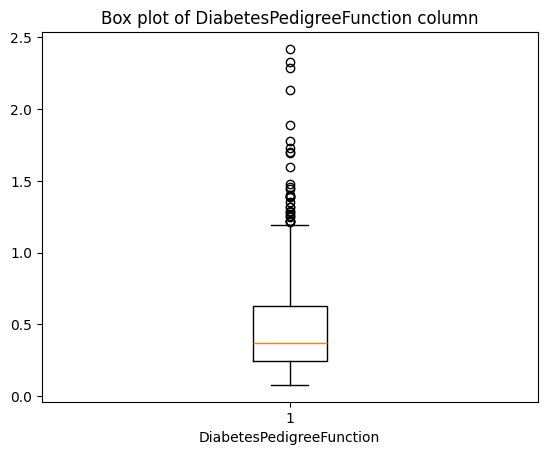

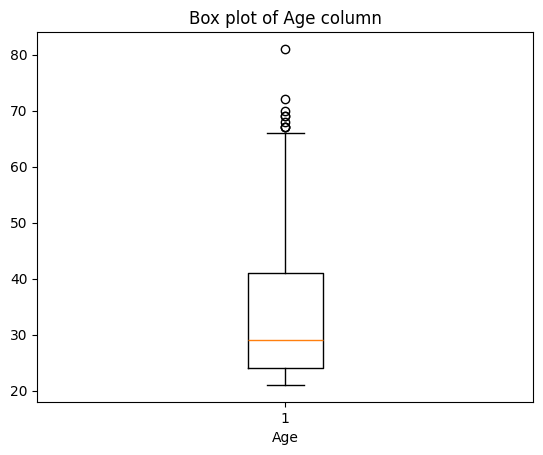

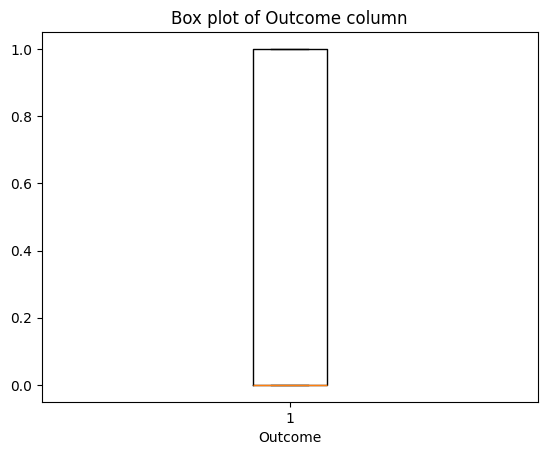

In [14]:
# lets check the distribution of the values in each columns 
plot_box(pima_df)

## Step 3: Data Preprocessing 

In [15]:
pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
y = pima_df["Outcome"]
X = pima_df.drop(columns = "Outcome")

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3 , random_state = 43)
print(f"""The shape of  X_train is {X_train.shape}, y_train is {y_train.shape} \n
While the shape of  X_test is {X_test.shape}, y_test is {y_test.shape}""")

The shape of  X_train is (537, 8), y_train is (537,) 

While the shape of  X_test is (231, 8), y_test is (231,)


## setting up an Evaluation function
this function will give us an ordered metrics of how good our model is 
and most importantly it will be used on baseline model and tuned model for more indepth evaluation
- confusion_matrix - (accuracy, precision,recall and F1 score)
- roc-auc:

### Explanation
- accuracy: this helps measure how good a model is at predicting
> Extra Read: The Accuracy is the number of correct predictions a divided by the total no of samples 
- precision: this helps measure how good the model is at differentiating between a positive and a negative class
>Extra Read: The precision is intuitively the ability of the classifier not to label as positive a sample that is negative.
    
- recall: this helps measure how good the model is at predicting positive class/ samples
> Extra Read: The recall is intuitively the ability of the classifier to find all the positive samples.

- F1 score: this is a balance score between precision and recall. its the best metric to use if you care about precision and recall both
> Extra Read: The F1 score can be interpreted as a harmonic mean of the precision and recall.

- roc-auc curve: this curve shows how well the model seperates the positive class from the negative class.
> Extra Read: AUC-ROC curve is a graph used to check how well a binary classification model works. It helps us to understand how well the model separates the positive cases like people with a disease from the negative cases like people without the disease at different threshold level.


- as a last metric i will be using the cell magic %%time to check how fast a cell ran so as to show the time taken to run diffrent tuning techniqes

In [63]:
def draw_roc_curve(y_true, y_pred):
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    plt.plot(fpr,tpr, label = "ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR (recall)")
    # find the threshold closest to zero 
    close_zero = np.argmin(np.abs(thresholds))
    plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize = 10,
            label = "threshold zero", fillstyle = "none", c = "k", mew = 2)
    plt.legend(loc = 4)
    plt.show()
    

def evaluate(y_true,y_pred):
    
    model_acc = accuracy_score(y_true,y_pred)
    print(f"Accuracy Score: {model_acc} ")

    model_acc = precision_score(y_true,y_pred)
    print(f"precision Score: {model_acc}")

    model_acc = recall_score(y_true,y_pred)
    print(f"recall Score: {model_acc}")

    model_acc = f1_score(y_true,y_pred)
    print(f"f1 Score: {model_acc}")

    draw_roc_curve(y_true, y_pred)


## Step 4: setting a baseline model performance 
we are going to be using only decision tree classifier model for this tuning and cross-validation testing to notice the differences in performance and time and score and so-on 

In [55]:
%%time
base_clf = DecisionTreeClassifier()

base_clf.fit(X_train, y_train)

base_pred = base_clf.predict(X_test)

CPU times: user 5.87 ms, sys: 3.02 ms, total: 8.88 ms
Wall time: 7.61 ms


Accuracy Score: 0.6536796536796536 
precision Score: 0.49382716049382713
recall Score: 0.5063291139240507
f1 Score: 0.5


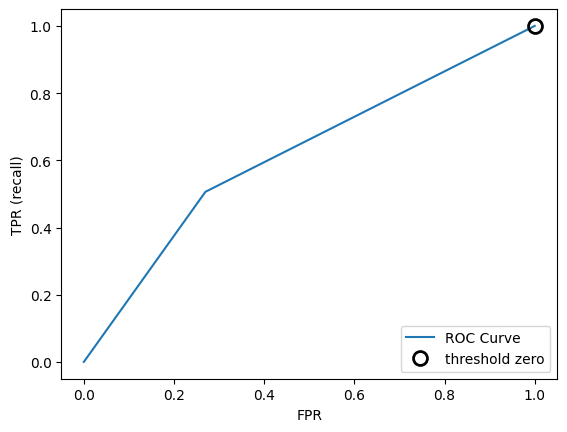

In [64]:
evaluate(y_test,base_pred)

## Step 4: Hyperparameter Tuning

### Step 4.0 : GridSearch 
#### Explanation 
a gridsearch hyperparameter tuning technique uses cross-validation (cv) to split the data into several sets of data (ie if  we set cv to 5 , cv splits our data into 4 different training sets and one test set so it then takes one training set and pairs it with out lone test set it does this for the rest also)

Gridsearch simply searches through our parameters one combination at a time (so for every parameter given it searches every posible combination with other parameters) by searches i mean it fits a model tuned to this parameters and tests it using cross-validation so you can see that it will be very slow.


In [66]:
%%time
# setting our paramenters 
param_grid = {
    "max_depth" :[2,5,7,10,15,20,25,50,100 ],
    "min_samples_split":[2,3,4,5],
    "min_samples_leaf":[1,2,3,4,5],
    "max_features" :[1,2,3,4,5]
         }

# setting the model
grid_clf = DecisionTreeClassifier(class_weight = "balanced")

# instantiating  randomSearchcv 
grids_cv = GridSearchCV(grid_clf, param_grid)

grid_search = grids_cv.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 100, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}
CPU times: user 19.4 s, sys: 5.56 ms, total: 19.4 s
Wall time: 19.4 s


Accuracy Score: 0.7489177489177489 
precision Score: 0.6666666666666666
recall Score: 0.5316455696202531
f1 Score: 0.5915492957746479


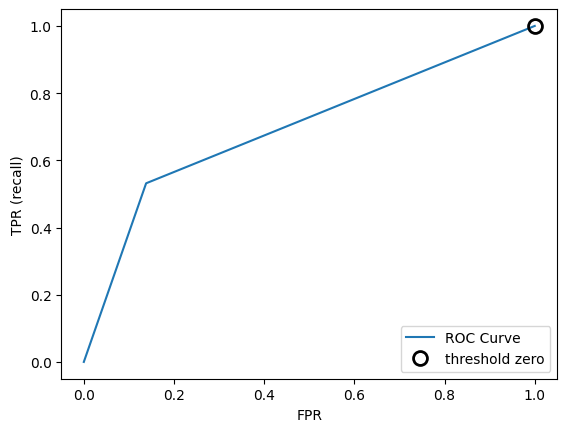

CPU times: user 98 ms, sys: 7 ms, total: 105 ms
Wall time: 102 ms


In [67]:
%%time
# creating a model using the parameters found
gridd_clf = DecisionTreeClassifier(max_depth=100,max_features = 5, min_samples_leaf = 4, min_samples_split = 5)

gridd_clf.fit(X_train, y_train)

grid_pred = gridd_clf.predict(X_test)

evaluate(y_test, grid_pred)

### Step 4.1 : RandomizedSearch
#### Explanation 
this also uses cross-validation but instead of searching every posible combination it randomly searches combinations this will work well if we have a large amount of parameters (gridsearch will be very slow )

In [69]:
%%time
# setting our paramenters 
param_grid = {
    "max_depth" :[2,5,7,10,15,20,25,34,44,49,50,100,122,125,134,137],
    "min_samples_split":[2,3,4,5],
    "min_samples_leaf":[1,2,3,4,5],
    "max_features" :[1,2,3,4,5]
         }

# setting the model
random_clf = DecisionTreeClassifier(class_weight = "balanced")

# instantiating  randomSearchcv 
randomcv = RandomizedSearchCV(random_clf, param_grid, n_iter = 20, random_state = 43 )

rand_search = randomcv.fit(X_train, y_train)

print(rand_search.best_params_)

{'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 3, 'max_depth': 134}
CPU times: user 448 ms, sys: 1.04 ms, total: 449 ms
Wall time: 447 ms


Accuracy Score: 0.7142857142857143 
precision Score: 0.6
recall Score: 0.4936708860759494
f1 Score: 0.5416666666666666


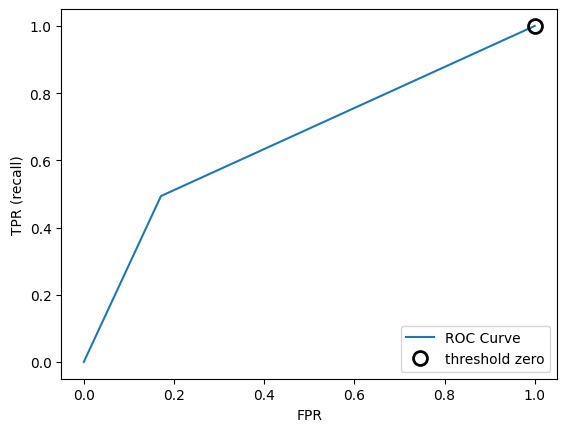

CPU times: user 97.1 ms, sys: 13 µs, total: 97.1 ms
Wall time: 95.3 ms


In [72]:
%%time
# creating a model using the parameters found
rand_clf = DecisionTreeClassifier(max_depth=100,max_features = 5, min_samples_leaf = 4, min_samples_split = 5)
rand_clf.fit(X_train, y_train)

rand_pred = rand_clf.predict(X_test)

evaluate(y_test, rand_pred)

>Note that we sacrificed some accuracy for some speed,
>gridsearch ran in 19 seconds way slower
>while
>randomizedsearch ran in 447ms which is way faster but less accurate

### Step 4.2 : Parameter selection and optimization 
#### Explanation 
this is when you are performing hyperparameter tuning you choose the best set of parameters that control an algorithms learning process 
for example notice that in the Gridsearch and Randomizedsearch above the only parameter hitting above 10 is max_depth this is beacause i have judged that the other parameters dont need to pass 5 so as not to start overfitting or underfitting , also the max_feature parameters max is 5 this is because the maximuim number of column in the data is 5.

### Step 4.2 : model performance comparision
#### Explanation 
when performing Hyperparameter tuning you need to firstly have a baseline model to check against (ours is 0.65 for accuracy ) which we will then compare against our tuned model and then find out the performance 
for example 
| scores|accuracy|precision|recall|f1_score|
|-------|--------|---------|------|--------|
|Baseline|0.65|0.49|0.50|0.5|
|gridsearch|0.74|0.66|0.53|0.59|
|randomsearch|0.71|0.6|0.49|0.54|

now we can compare and check the best model performance 

## Step 5: cross-validation
#### Cross-validation scoring
like i explained in gridsearch cross-validation a method of spliting your data into n number of sets and then testing on it (ie if  we set cv to 5 , cv splits our data into 4 different training sets and one test set so it then takes one training set and pairs it with out lone test set it does this for the rest also)

#### k-fold cross-validation
but if we come across with a data that its classes are not scattered in the data but are ordered for example (first 50% of data is class 0, then the second 50 percent of the data is class 1)
for this case we use `k-fold cross-validation` k-fold ensures that each fold/set has its own test set

A more advanced method is `stratified k-fold cross-validation` this makes sure that each fold/set is of the same distribution as the original data (eg if original is 70% class 0 and 30% class 1) then stratified k-fold is the same.

#### train/test split validation 
we have been using this method for some time now its the basic create a train data create a test data then evaluate on how well your model generalizes 
theres also another variant we can add validation data to the cycle (so we create a training data, then a validation data then a testing data) the validation data acts as a data that we can use to freely test the model then the test data is only to check if the model generalizes cause the model only sees this dataset once therefore preventing data leakage and also acting as an extremly valid evaluation

In [76]:
#cross-validation scoring 
"""
cross-validation can be used on its own to test your models performance instead of using it with gridsearch or randomsearch
"""
cross_val_clf = DecisionTreeClassifier()
cross_val_score(cross_val_clf, X_train, y_train)


array([0.71296296, 0.68518519, 0.61682243, 0.72897196, 0.68224299])

In [77]:
#k-fold cross validation 
"""
to implement k-fold you insert it into cross_val_score
"""
kfold = KFold(n_splits = 6 )

cross_kf_clf = DecisionTreeClassifier()
cross_val_score(cross_kf_clf, X_train, y_train, cv = kfold)

array([0.65555556, 0.66666667, 0.7       , 0.60674157, 0.74157303,
       0.74157303])

>Note: we can use gridsearch and randomizedsearch with k-fold and stratified k-fold

## Step 6: Bias-Variance Tradeoff
### Overfitting 
Overfitting is when you build a model that is too complex for the amount of information(data) we have. it Occurs when you fit a model too closly to the particularities of the training set and therefore obtain a model that works well on the training set but is unable to generalise to new and unseen data 
### Underfitting 
on the other hand if your model is too simple then the model might not be able to capture all the aspects of and variability in the data and the model will do badly even on the training data.

### Model generalization
this is training a model with the sweet spot between overfiting and underfitting in mind 

### Strategies for balancing bias and variance

1. Model Selection: Choose a model that is appropriate for the complexity of the data. For example, if the data has a nonlinear relationship, consider using a nonlinear model rather than a linear one.
2. Cross-Validation: Use cross-validation to evaluate the performance of the model and tune hyperparameters to find the optimal balance between bias and variance.
3. Feature Engineering: Improve the quality of the features used in the model. This can help reduce bias and improve the model's ability to capture the underlying patterns in the data.